# Analysis of Study Data

Prolific participants only. Auto-detects the export timestamp from CSV files in this directory.


## Setup

In [22]:
# Install required packages (uncomment and run if needed)
#!pip install pandas matplotlib seaborn ipywidgets

# Note: json, glob, os, and html are built-in Python modules — no installation needed


In [23]:
import glob
import json
import os
from html import escape
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

# Ensure working directory is the notebook's directory (VS Code sets cwd to repo root)
if not glob.glob('moderation_sessions_export_*.csv'):
    _candidates = sorted(glob.glob('data-exports/*/moderation_sessions_export_*.csv'))
    if _candidates:
        os.chdir(os.path.dirname(_candidates[-1]))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260412_180829


### Data Loading and Filtering


In [24]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Set DEV_MODE = True to skip Prolific PID filtering (useful for dev/test data)
DEV_MODE = False

# Auto-detect export timestamp from CSV files in this directory
_mod_files = sorted(glob.glob('moderation_sessions_export_*.csv'))
if not _mod_files:
    raise FileNotFoundError(
        "No moderation_sessions_export_*.csv found in current directory. "
        "Run the export script first, then open the notebook from its export folder."
    )

EXPORT_TIMESTAMP = _mod_files[-1].replace('moderation_sessions_export_', '').replace('.csv', '')
print(f"Detected export timestamp: {EXPORT_TIMESTAMP}")
print(f"DEV_MODE: {DEV_MODE}")

# --- Load all data files ---
moderation_df      = pd.read_csv(f'moderation_sessions_export_{EXPORT_TIMESTAMP}.csv')
child_profiles_df  = pd.read_csv(f'child_profiles_export_{EXPORT_TIMESTAMP}.csv')
exit_quiz_df       = pd.read_csv(f'exit_quiz_responses_export_{EXPORT_TIMESTAMP}.csv')
assignment_time_df = pd.read_csv(f'assignment_time_export_{EXPORT_TIMESTAMP}.csv')

# Load new tables if available
_concern_file = f'concern_items_export_{EXPORT_TIMESTAMP}.csv'
if os.path.exists(_concern_file):
    concern_items_df = pd.read_csv(_concern_file)
else:
    concern_items_df = pd.DataFrame()

_selections_file = f'selections_export_{EXPORT_TIMESTAMP}.csv'
if os.path.exists(_selections_file):
    selections_df = pd.read_csv(_selections_file)
else:
    selections_df = pd.DataFrame()

_users_file = f'users_export_{EXPORT_TIMESTAMP}.csv'
if os.path.exists(_users_file):
    users_df = pd.read_csv(_users_file)
else:
    print(f"WARNING: {_users_file} not found — users_df will be empty.")
    users_df = pd.DataFrame()

print(f"\nRaw row counts:")
print(f"  Users:               {len(users_df)}")
print(f"  Moderation sessions: {len(moderation_df)}")
print(f"  Child profiles:      {len(child_profiles_df)}")
print(f"  Exit quiz responses: {len(exit_quiz_df)}")
print(f"  Assignment time:     {len(assignment_time_df)}")
print(f"  Concern items:       {len(concern_items_df)}")
print(f"  Selections:          {len(selections_df)}")

if DEV_MODE:
    print("\n⚠ DEV_MODE enabled — skipping Prolific PID filter, keeping all non-admin users")
    if len(users_df) > 0 and 'role' in users_df.columns:
        prolific_user_ids = set(users_df.loc[users_df['role'] != 'admin', 'id'])
    else:
        prolific_user_ids = set(moderation_df['user_id'].unique())
else:
    # --- Filter to Prolific participants only ---
    # Exclude admin users AND require a real prolific_pid (not placeholder values like '1')
    def _is_prolific(row):
        pid = row.get('prolific_pid')
        role = row.get('role', '')
        if str(role).strip().lower() == 'admin':
            return False
        if pd.isna(pid):
            return False
        s = str(pid).strip()
        # Filter out empty, numeric-only placeholders, and other non-Prolific IDs
        if not s or s in ('nan', 'null', 'none'):
            return False
        # Real Prolific PIDs are 24-char hex strings; reject short/numeric placeholders
        if len(s) < 10:
            return False
        return True

    if len(users_df) > 0 and 'prolific_pid' in users_df.columns:
        prolific_user_ids = set(users_df.loc[users_df.apply(_is_prolific, axis=1), 'id'])
    else:
        prolific_user_ids = set(
            moderation_df.loc[moderation_df.apply(_is_prolific, axis=1), 'user_id']
        )

moderation_df      = moderation_df[moderation_df['user_id'].isin(prolific_user_ids)].copy()
child_profiles_df  = child_profiles_df[child_profiles_df['user_id'].isin(prolific_user_ids)].copy()
exit_quiz_df       = exit_quiz_df[exit_quiz_df['user_id'].isin(prolific_user_ids)].copy()
assignment_time_df = assignment_time_df[assignment_time_df['user_id'].isin(prolific_user_ids)].copy()
if len(users_df) > 0:
    users_df = users_df[users_df['id'].isin(prolific_user_ids)].copy()
if len(concern_items_df) > 0 and 'user_id' in concern_items_df.columns:
    concern_items_df = concern_items_df[concern_items_df['user_id'].isin(prolific_user_ids)].copy()
if len(selections_df) > 0 and 'user_id' in selections_df.columns:
    selections_df = selections_df[selections_df['user_id'].isin(prolific_user_ids)].copy()

print(f"\nAfter filtering to {len(prolific_user_ids)} participant(s):")
print(f"  Users:               {len(users_df)}")
print(f"  Moderation sessions: {len(moderation_df)}")
print(f"  Child profiles:      {len(child_profiles_df)}")
print(f"  Exit quiz responses: {len(exit_quiz_df)}")
print(f"  Assignment time:     {len(assignment_time_df)}")
print(f"  Concern items:       {len(concern_items_df)}")
print(f"  Selections:          {len(selections_df)}")

Detected export timestamp: 20260412_180829
DEV_MODE: False

Raw row counts:
  Users:               32
  Moderation sessions: 101
  Child profiles:      29
  Exit quiz responses: 22
  Assignment time:     1147
  Concern items:       195
  Selections:          253

After filtering to 31 participant(s):
  Users:               31
  Moderation sessions: 97
  Child profiles:      28
  Exit quiz responses: 21
  Assignment time:     1131
  Concern items:       191
  Selections:          249


In [25]:
# Parse a list of prolific PIDs and filter to only those participants

if DEV_MODE:
    print("⚠ DEV_MODE — skipping Prolific PID filter cell")
else:
    def parse_prolific_pids(text_block: str):
        """Extract unique Prolific-style 24-char hex IDs from a mixed text block."""
        seen = set()
        pids = []
        for line in text_block.splitlines():
            s = line.strip()
            if len(s) == 24 and all(ch in "0123456789abcdefABCDEF" for ch in s):
                pid = s.lower()
                if pid not in seen:
                    seen.add(pid)
                    pids.append(pid)
        return pids

    raw_pid_block = """
673d25851173193daa4771ca
10 Apr 2026, 15:03
00:35:11
COMPLETED

69b9174a05fa2db6d0a8b4ff
10 Apr 2026, 15:07
00:38:53
COMPLETED

62b5e825a5e8616bde25741d
10 Apr 2026, 15:07
00:36:30
COMPLETED

671e55aeca0216c5762de35a
10 Apr 2026, 15:09
00:08:19
COMPLETED

66639889ea005547089b6cbf
10 Apr 2026, 15:11
00:24:30
    """

    pids_to_keep = parse_prolific_pids(raw_pid_block)
    if pids_to_keep:
        print(f"Parsed {len(pids_to_keep)} PID(s): {pids_to_keep}")
        filtered_user_ids = set(
            users_df.loc[users_df['prolific_pid'].isin(pids_to_keep), 'id']
        )
        moderation_df      = moderation_df[moderation_df['user_id'].isin(filtered_user_ids)].copy()
        child_profiles_df  = child_profiles_df[child_profiles_df['user_id'].isin(filtered_user_ids)].copy()
        exit_quiz_df       = exit_quiz_df[exit_quiz_df['user_id'].isin(filtered_user_ids)].copy()
        assignment_time_df = assignment_time_df[assignment_time_df['user_id'].isin(filtered_user_ids)].copy()
        users_df           = users_df[users_df['id'].isin(filtered_user_ids)].copy()
        if len(concern_items_df) > 0 and 'user_id' in concern_items_df.columns:
            concern_items_df = concern_items_df[concern_items_df['user_id'].isin(filtered_user_ids)].copy()
        if len(selections_df) > 0 and 'user_id' in selections_df.columns:
            selections_df = selections_df[selections_df['user_id'].isin(filtered_user_ids)].copy()

        print(f"\nAfter filtering to {len(filtered_user_ids)} participant(s) by PID:")
        print(f"  Moderation sessions: {len(moderation_df)}")
    else:
        print("No PIDs specified — keeping all filtered participants.")

Parsed 5 PID(s): ['673d25851173193daa4771ca', '69b9174a05fa2db6d0a8b4ff', '62b5e825a5e8616bde25741d', '671e55aeca0216c5762de35a', '66639889ea005547089b6cbf']

After filtering to 5 participant(s) by PID:
  Moderation sessions: 20


In [26]:
# Schema guard & normalization — handles minor column changes between export versions
print("Schema check:")
for _name, _df in [
    ('moderation_df',      moderation_df),
    ('child_profiles_df',  child_profiles_df),
    ('exit_quiz_df',       exit_quiz_df),
    ('assignment_time_df', assignment_time_df),
    ('users_df',           users_df),
]:
    print(f"  {_name}: {len(_df)} rows, {len(_df.columns)} columns")

# Ensure all columns the analysis relies on exist in moderation_df
_mod_required = [
    'prolific_pid', 'user_id', 'session_number', 'session_id', 'scenario_index', 'strategies',
    'session_metadata', 'original_response', 'initial_decision', 'refactored_response',
    'custom_instructions', 'child_name', 'child_age', 'id', 'is_attention_check',
    'concern_level', 'concern_reason', 'realism_level', 'highlighted_texts',
    'is_final_version', 'scenario_prompt',
]
for _c in _mod_required:
    if _c not in moderation_df.columns:
        print(f"  Adding missing column '{_c}' to moderation_df (filled with None)")
        moderation_df[_c] = None


# Ensure session_id exists in auxiliary dataframes (backfill for new schema)
for _col in ['session_number', 'session_id']:
    for _df_name, _df in [
        ('assignment_time_df', assignment_time_df),
        ('child_profiles_df',  child_profiles_df),
        ('concern_items_df',   concern_items_df),
    ]:
        if _col not in _df.columns:
            print(f"  Adding missing column '{_col}' to {_df_name} (filled with None)")
            _df[_col] = None

# Normalize JSON-serialized text columns so downstream parsing is safe
moderation_df['strategies']        = moderation_df['strategies'].fillna('[]').astype(str)
moderation_df['session_metadata']  = moderation_df['session_metadata'].fillna('').astype(str)
moderation_df['highlighted_texts'] = moderation_df['highlighted_texts'].fillna('[]').astype(str)

# Coerce numeric columns
for _col in ['concern_level', 'realism_level', 'satisfaction_level', 'scenario_index',
             'session_number', 'is_attention_check', 'is_final_version']:
    if _col in moderation_df.columns:
        moderation_df[_col] = pd.to_numeric(moderation_df[_col], errors='coerce')

print("\nNormalization complete.")

Schema check:
  moderation_df: 20 rows, 38 columns
  child_profiles_df: 5 rows, 22 columns
  exit_quiz_df: 5 rows, 17 columns
  assignment_time_df: 299 rows, 11 columns
  users_df: 5 rows, 17 columns
  Adding missing column 'session_number' to moderation_df (filled with None)
  Adding missing column 'is_attention_check' to moderation_df (filled with None)
  Adding missing column 'session_number' to assignment_time_df (filled with None)
  Adding missing column 'session_number' to child_profiles_df (filled with None)
  Adding missing column 'session_number' to concern_items_df (filled with None)

Normalization complete.


## Time Spent Per Session


In [27]:
# Time spent per participant per session
# active_ms_delta = time since last heartbeat ping (most reliable for true active time)
# cumulative_ms   = running total reported by the client

_tmp = assignment_time_df.copy()

# Join with users_df to get prolific_pid from user_id
if len(users_df) > 0 and 'prolific_pid' in users_df.columns:
    _user_lookup = users_df[['id', 'prolific_pid']].rename(columns={'id': 'user_id'})
    _tmp = _tmp.merge(_user_lookup, on='user_id', how='left', suffixes=('_orig', ''))
    if 'prolific_pid_orig' in _tmp.columns:
        _tmp.drop(columns=['prolific_pid_orig'], inplace=True)

_tmp['active_ms_delta'] = pd.to_numeric(_tmp['active_ms_delta'], errors='coerce').fillna(0)
_tmp['cumulative_ms']   = pd.to_numeric(_tmp['cumulative_ms'],   errors='coerce').fillna(0)

time_by_user_session = (
    _tmp.groupby(['user_id', 'prolific_pid', 'session_id', 'attempt_number'], dropna=False)
        .agg(
            events            = ('id',              'count'),
            total_active_ms   = ('active_ms_delta', 'sum'),
            max_cumulative_ms = ('cumulative_ms',   'max'),
            first_event_at    = ('created_at',      'min'),
            last_event_at     = ('created_at',      'max'),
        )
        .reset_index()
)

time_by_user_session['total_active_minutes']   = time_by_user_session['total_active_ms']   / 60_000
time_by_user_session['max_cumulative_minutes'] = time_by_user_session['max_cumulative_ms'] / 60_000
time_by_user_session = time_by_user_session.sort_values(['prolific_pid', 'session_id', 'attempt_number'])

print("Time spent per participant per session:\n")
print(
    time_by_user_session[
        ['prolific_pid', 'session_id', 'attempt_number', 'events',
         'total_active_minutes', 'max_cumulative_minutes']
    ].to_string(index=False)
)

Time spent per participant per session:

            prolific_pid               session_id  attempt_number  events  total_active_minutes  max_cumulative_minutes
62b5e825a5e8616bde25741d 69d8f618778088f3230cc085               1      71             30.300000               30.300000
66639889ea005547089b6cbf 69d8f705ab4a65fcae502a26               1      55             23.866667               23.866667
671e55aeca0216c5762de35a 69d8f694cd975704f7067a14               1      22              7.450000                7.450000
673d25851173193daa4771ca 69d8f52dc81321dc502360af               1      73             30.383333               30.383333
69b9174a05fa2db6d0a8b4ff 69d8f4c4377fde59defc9484               1      78             28.766667               28.766667


## Time Distribution


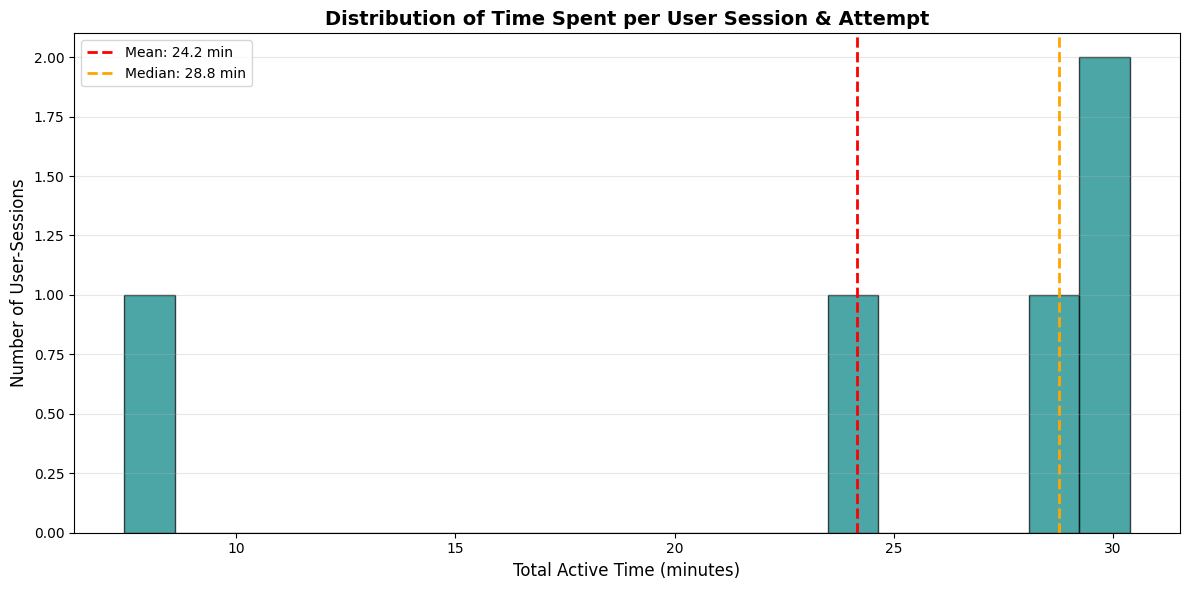


Time per user-session statistics (active time):
count     5.000000
mean     24.153333
std       9.707739
min       7.450000
25%      23.866667
50%      28.766667
75%      30.300000
max      30.383333
Name: total_active_minutes, dtype: float64

Total number of user-sessions: 5


In [28]:
# Plot distribution of time spent per user
# Note: Uses time_by_user_session which aggregates total active time per user per session/attempt
if len(time_by_user_session) > 0:
    plt.figure(figsize=(12, 6))
    plt.hist(time_by_user_session['total_active_minutes'], bins=20, color='teal', edgecolor='black', alpha=0.7)
    plt.xlabel('Total Active Time (minutes)', fontsize=12)
    plt.ylabel('Number of User-Sessions', fontsize=12)
    plt.title('Distribution of Time Spent per User Session & Attempt', fontsize=14, fontweight='bold')
    plt.axvline(time_by_user_session['total_active_minutes'].mean(), color='red', linestyle='--', 
                label=f"Mean: {time_by_user_session['total_active_minutes'].mean():.1f} min", linewidth=2)
    plt.axvline(time_by_user_session['total_active_minutes'].median(), color='orange', linestyle='--', 
                label=f"Median: {time_by_user_session['total_active_minutes'].median():.1f} min", linewidth=2)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTime per user-session statistics (active time):")
    stats = time_by_user_session['total_active_minutes'].describe()
    print(stats)
    print(f"\nTotal number of user-sessions: {len(time_by_user_session)}")
else:
    print("No time data available.")

In [29]:
# Per-participant median active time across their sessions and attempts
per_user_time = (
    time_by_user_session
    .groupby(['prolific_pid', 'session_id', 'attempt_number'], dropna=False)['total_active_minutes']
    .agg(events='count', median_min='median', mean_min='mean', total_min='sum')
    .reset_index()
    .sort_values(['prolific_pid', 'session_id', 'attempt_number'], ascending=[True, True, True])
    .rename(columns={
        'events':       'events',
        'median_min':   'median_active_min',
        'mean_min':     'mean_active_min',
        'total_min':    'total_active_min',
    })
)

print("Per-participant time summary by session & attempt:\n")
print(per_user_time.to_string(index=False))
print(f"\nOverall median across all user-sessions: "
      f"{time_by_user_session['total_active_minutes'].median():.2f} min")

Per-participant time summary by session & attempt:

            prolific_pid               session_id  attempt_number  events  median_active_min  mean_active_min  total_active_min
62b5e825a5e8616bde25741d 69d8f618778088f3230cc085               1       1          30.300000        30.300000         30.300000
66639889ea005547089b6cbf 69d8f705ab4a65fcae502a26               1       1          23.866667        23.866667         23.866667
671e55aeca0216c5762de35a 69d8f694cd975704f7067a14               1       1           7.450000         7.450000          7.450000
673d25851173193daa4771ca 69d8f52dc81321dc502360af               1       1          30.383333        30.383333         30.383333
69b9174a05fa2db6d0a8b4ff 69d8f4c4377fde59defc9484               1       1          28.766667        28.766667         28.766667

Overall median across all user-sessions: 28.77 min


## Attention Check Results


In [30]:
def _has_highlight(text):
    """Determine if the highlighted_texts column indicates a highlight was made."""
    if pd.isna(text) or str(text).strip() in ('', '[]'):
        return False
    try:
        items = json.loads(text)
        return isinstance(items, list) and len(items) > 0
    except json.JSONDecodeError:
        return False
moderation_df['has_highlight'] = moderation_df['highlighted_texts'].apply(_has_highlight)
moderation_df['is_skip']        = ~moderation_df['has_highlight']
moderation_df['is_skip']

55     False
56      True
57     False
58      True
61     False
62     False
63     False
64     False
77     False
78     False
79     False
80     False
85     False
86     False
87     False
88     False
97     False
98     False
99     False
100    False
Name: is_skip, dtype: bool

In [31]:
# Child profile summary per participant
# Pulled from child_profiles_df (latest attempt per participant).

_id_col = 'user_id' if DEV_MODE else 'prolific_pid'

_cp = child_profiles_df[child_profiles_df[_id_col].notna()].copy()
if 'attempt_number' in _cp.columns:
    _cp = _cp.sort_values('attempt_number', ascending=True)

child_summary = (
    _cp.groupby(_id_col, sort=False)
    .last()
    [['name', 'child_age', 'child_gender', 'child_characteristics',
      'child_ai_use_contexts', 'child_internet_use_frequency']]
    .reset_index()
    .sort_values(_id_col)
)

print("Child profile per participant:\n")
print(child_summary.to_string(index=False))

Child profile per participant:

            prolific_pid  name    child_age child_gender  child_characteristics  child_ai_use_contexts  child_internet_use_frequency
62b5e825a5e8616bde25741d   fay 15 years old       Female                    NaN                    NaN                             8
66639889ea005547089b6cbf   Cam 15 years old         Male                    NaN                    NaN                             8
671e55aeca0216c5762de35a   Tom 11 years old         Male                    NaN                    NaN                             8
673d25851173193daa4771ca Tegan  9 years old       Female                    NaN                    NaN                             8
69b9174a05fa2db6d0a8b4ff Eric   9 years old         Male                    NaN                    NaN                             6


In [32]:
display(exit_quiz_df)
pd.json_normalize(exit_quiz_df['answers'].apply(json.loads))

,id,user_id,child_id,answers,score,meta,attempt_number,is_current,created_at,updated_at,user_name,user_email,user_role,prolific_pid,child_name,child_age,child_gender
11,1f0bc6a6-290f-4369-a701-a061b5e1261a,aae34961-d3ea-4772-a027-5ebf40ababf1,887f41cb-a749-46d1-8a0f-a5ff601deb4b,"{""parentGender"": ""male"", ""parentAge"": ""45-54"",...",NaN,"{""page"": ""exit-survey""}",1,True,1775827080168,1775827080168,671e55aeca0216c5762de35a,prolific_671e55aeca0216c5762de35a@prolific.study,prolific,671e55aeca0216c5762de35a,Tom,11 years old,Male
12,db183c91-f491-4416-9a97-36ea22b4fca0,bb385a79-a474-40cb-abd9-59c7bd5fdc39,d803af32-22e3-4c64-b8cc-2cd60a8dcc4e,"{""parentGender"": ""male"", ""parentAge"": ""35-44"",...",NaN,"{""page"": ""exit-survey""}",1,True,1775828704292,1775828704292,69b9174a05fa2db6d0a8b4ff,prolific_69b9174a05fa2db6d0a8b4ff@prolific.study,prolific,69b9174a05fa2db6d0a8b4ff,Eric,9 years old,Male
16,fba2fef6-ed86-4cb1-a990-133a46732c09,e064abd5-68d7-4677-9cdf-b2a3e0099e31,db4dfa90-bd16-41ac-960e-9b1f44544278,"{""parentGender"": ""female"", ""parentAge"": ""45-54...",NaN,"{""page"": ""exit-survey""}",1,True,1775828158797,1775828158797,66639889ea005547089b6cbf,prolific_66639889ea005547089b6cbf@prolific.study,prolific,66639889ea005547089b6cbf,Cam,15 years old,Male
18,4d21ece7-0e0f-4fa4-bf08-7ef638f00f50,e1b1d1cd-61cd-4fd7-8679-c3bc2e2e8c5c,2d114602-906c-42b4-b04a-01b97f844783,"{""parentGender"": ""female"", ""parentAge"": ""35-44...",NaN,"{""page"": ""exit-survey""}",1,True,1775828645118,1775828645118,62b5e825a5e8616bde25741d,prolific_62b5e825a5e8616bde25741d@prolific.study,prolific,62b5e825a5e8616bde25741d,fay,15 years old,Female
21,570403b3-70d1-4de6-a4b1-161c57d543a4,f59ecfa3-c8eb-45b4-a41e-9e4e33846ab7,e741e2aa-7776-4deb-ad04-9a242d2359a5,"{""parentGender"": ""female"", ""parentAge"": ""25-34...",NaN,"{""page"": ""exit-survey""}",1,True,1775828329972,1775828329972,673d25851173193daa4771ca,prolific_673d25851173193daa4771ca@prolific.study,prolific,673d25851173193daa4771ca,Tegan,9 years old,Female


,parentGender,parentAge,areaOfResidency,parentEducation,parentEthnicity,genaiFamiliarity,genaiUsageFrequency,parentInternetUseFrequency,parentingStyle,attentionCheck,isOnlyChild,childHasAIUse,childAIUseContexts,parentLLMMonitoringLevel,childGenderOther,childAIUseContextsOther,parentLLMMonitoringOther,childInternetUseFrequency,childPersonalitySubCharacteristics,childAdditionalInfo
0,male,45-54,rural,bachelors,[white],regular_user,daily,8,"[A, D]",strongly_disagree,yes,yes,"[school_homework, general_knowledge]",active_rules,,,,8,"[organized, efficient, persistent, dependable,...",My child loves videos games and sports.
1,male,35-44,suburban,bachelors,[white],regular_user,daily,8,[A],strongly_disagree,no,yes,[games_chatting],active_rules,,,,5,"[compassionate, forgiving, organized, talkativ...",they are creative
2,female,45-54,suburban,associates,[black-african-american],regular_user,daily,8,[C],strongly_disagree,no,yes,"[school_homework, general_knowledge, games_cha...",no_monitoring,,,,8,"[unsympathetic, fault_finding, organized, effi...",None that I can think of.
3,female,35-44,suburban,high-school,"[white, black-african-american]",regular_user,daily,8,[A],strongly_disagree,no,yes,"[school_homework, personal_advice]",plan_to,,,,8,"[argumentative, fault_finding, lazy, careless,...",My child gives queen B energy. very proudful a...
4,female,25-34,suburban,high-school,[white],regular_user,daily,8,"[A, D]",strongly_disagree,yes,no,[],not_applicable,,,,8,"[compassionate, helpful, respectful, forgiving...",She enjoys inventing things and has a very ima...


### Consistency Check: Child Internet Use Frequency

Compare the `child_internet_use_frequency` field from the **child profile** with the
`childInternetUseFrequency` answer from the **exit survey** to check for consistency.

In [33]:
# ── Consistency check: child_internet_use_frequency ──────────────────────────
# Compare child-profile value vs exit-survey answer for the same question.
# Deduplicates by keeping the last row per participant (highest attempt_number).

_id_col = 'user_id' if DEV_MODE else 'prolific_pid'

# Profile value — one row per participant (last attempt)
_prof_filtered = child_profiles_df[
    child_profiles_df['is_current'].astype(str).str.strip().str.lower().isin(['true', '1'])
].copy()
if 'attempt_number' in _prof_filtered.columns:
    _prof_filtered = _prof_filtered.sort_values('attempt_number')
profile_freq = (
    _prof_filtered
    .groupby(_id_col, sort=False)['child_internet_use_frequency']
    .last()
    .rename('profile_value')
)

# Exit-survey value — one row per participant (last attempt)
def _extract_exit_freq(row):
    try:
        ans = json.loads(row['answers']) if isinstance(row['answers'], str) else row['answers']
        if isinstance(ans, dict):
            return ans.get('childInternetUseFrequency')
        if isinstance(ans, list):
            for item in ans:
                if isinstance(item, dict) and item.get('id') == 'childInternetUseFrequency':
                    return item.get('value')
    except Exception:
        pass
    return None

_exit_filtered = exit_quiz_df[
    exit_quiz_df['is_current'].astype(str).str.strip().str.lower().isin(['true', '1'])
].copy()
_exit_filtered['exit_value'] = _exit_filtered.apply(_extract_exit_freq, axis=1)
if 'attempt_number' in _exit_filtered.columns:
    _exit_filtered = _exit_filtered.sort_values('attempt_number')
exit_freq = (
    _exit_filtered
    .groupby(_id_col, sort=False)['exit_value']
    .last()
    .rename('exit_value')
)

comparison = pd.concat([profile_freq, exit_freq], axis=1).dropna(how='all')
comparison['match'] = (
    comparison['profile_value'].astype(str).str.lower()
    == comparison['exit_value'].astype(str).str.lower()
)

n_total   = len(comparison)
n_match   = comparison['match'].sum()
n_mismatch = n_total - n_match

print(f'Participants with both values: {n_total}')
print(f'  Matching:    {n_match}')
print(f'  Mismatched:  {n_mismatch}')
if n_mismatch > 0:
    print('\nMismatched rows:')
    display(comparison[~comparison['match']])
else:
    print('\nAll responses are consistent ✓')
display(comparison)

Participants with both values: 5
  Matching:    4
  Mismatched:  1

Mismatched rows:


,profile_value,exit_value,match
prolific_pid,,,
69b9174a05fa2db6d0a8b4ff,6,5,False


,profile_value,exit_value,match
prolific_pid,,,
671e55aeca0216c5762de35a,8,8,True
69b9174a05fa2db6d0a8b4ff,6,5,False
66639889ea005547089b6cbf,8,8,True
62b5e825a5e8616bde25741d,8,8,True
673d25851173193daa4771ca,8,8,True


### Skips vs Highlighted Scenarios

A **skip** is any final-version scenario where `highlighted_texts` is empty or `[]`. Attention-check scenarios are excluded.


In [34]:
# Restrict to final-version, non-attention-check rows for skip/highlight analysis
_mod_final = moderation_df[
    (moderation_df["is_final_version"] == 1) &
    (moderation_df["is_attention_check"] != 1)
].copy()

_mod_final["is_highlighted"] = _mod_final["highlighted_texts"].apply(_has_highlight)
_mod_final["is_skip"]        = ~_mod_final["is_highlighted"]

def _count_highlights(text):
    if pd.isna(text) or str(text).strip() in ("", "[]"):
        return 0
    try:
        items = json.loads(text)
        return len(items) if isinstance(items, list) else 0
    except json.JSONDecodeError:
        return 0

_mod_final["n_highlights"] = _mod_final["highlighted_texts"].apply(_count_highlights)

total         = len(_mod_final)
n_highlighted = int(_mod_final["is_highlighted"].sum())
n_skipped     = int(_mod_final["is_skip"].sum())
pct_hi        = 100 * n_highlighted / total if total > 0 else 0

print("Overall scenarios (final versions, non-attention-check):")
print(f"  Total scenarios    : {total}")
print(f"  Highlighted        : {n_highlighted}  ({pct_hi:.1f}%)")
print(f"  Skipped            : {n_skipped}  ({100 - pct_hi:.1f}%)")
_total_hl = int(_mod_final["n_highlights"].sum())
print(f"  Total highlights   : {_total_hl}")

Overall scenarios (final versions, non-attention-check):
  Total scenarios    : 20
  Highlighted        : 18  (90.0%)
  Skipped            : 2  (10.0%)
  Total highlights   : 42


In [35]:
# Per-participant breakdown (uses _mod_final from cell above)
group_col = "user_id" if DEV_MODE else "prolific_pid"

per_user_skip = (
    _mod_final.groupby(group_col, dropna=False)
    .agg(
        total=("id", "count"),
        highlighted=("is_highlighted", "sum"),
        skipped=("is_skip", "sum"),
        total_highlights=("n_highlights", "sum"),
    )
    .reset_index()
)

for _c in ["total", "highlighted", "skipped", "total_highlights"]:
    per_user_skip[_c] = pd.to_numeric(per_user_skip[_c], errors="coerce").fillna(0).astype(int)

per_user_skip["pct_highlighted"] = (
    100 * per_user_skip["highlighted"] / per_user_skip["total"].replace(0, pd.NA)
).fillna(0).round(1)

per_user_skip = per_user_skip.sort_values("pct_highlighted", ascending=False)

print("Per-participant skip vs highlight:")
print(per_user_skip.to_string(index=False))

Per-participant skip vs highlight:
            prolific_pid  total  highlighted  skipped  total_highlights  pct_highlighted
62b5e825a5e8616bde25741d      4            4        0                 7            100.0
66639889ea005547089b6cbf      4            4        0                13            100.0
673d25851173193daa4771ca      4            4        0                13            100.0
69b9174a05fa2db6d0a8b4ff      4            4        0                 6            100.0
671e55aeca0216c5762de35a      4            2        2                 3             50.0


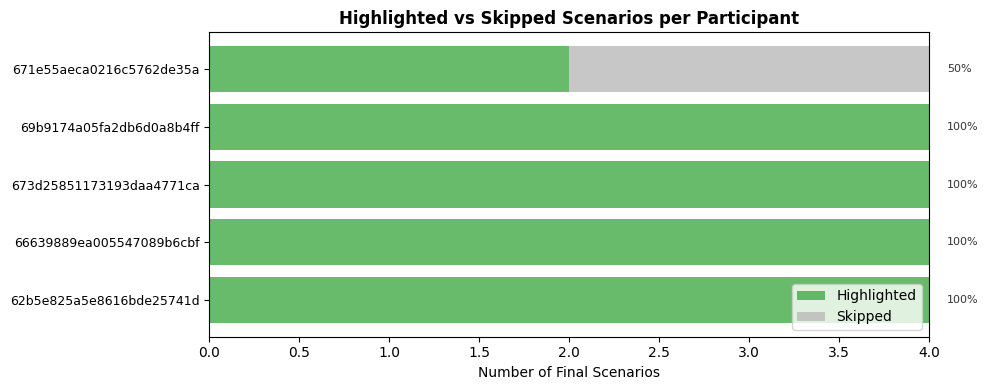

In [36]:
# Stacked horizontal bar chart — highlighted (green) vs skipped (gray) per participant
#_sorted = per_user_skip.sort_values('pct_highlighted', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(per_user_skip) * 0.5 + 1.5)))

pids    = per_user_skip['prolific_pid'].fillna('(no pid)').astype(str).tolist()
hi_vals = per_user_skip['highlighted'].tolist()
sk_vals = per_user_skip['skipped'].tolist()
y_pos   = list(range(len(pids)))

ax.barh(y_pos, hi_vals,              color='#4caf50', label='Highlighted', alpha=0.85)
ax.barh(y_pos, sk_vals, left=hi_vals, color='#bdbdbd', label='Skipped',    alpha=0.85)

# Annotate pct highlighted at the right edge of each bar
for i, (row) in enumerate(per_user_skip.itertuples()):
    ax.text(
        row.total + 0.1, i,
        f"{row.pct_highlighted:.0f}%",
        va='center', fontsize=8, color='#333',
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(pids, fontsize=9)
ax.set_xlabel('Number of Final Scenarios')
ax.set_title('Highlighted vs Skipped Scenarios per Participant', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Per-Participant Summary Export

In [37]:
# ── Per-Participant Summary Export ────────────────────────────────────────────
# One row per participant in original pasted PID order.

import json as _json

# 1. Ordered PID list
summary = pd.DataFrame({'PID': pids_to_keep})

# 2. Map PID → user_id
pid_uid = users_df[['id', 'prolific_pid']].rename(columns={'id': 'user_id', 'prolific_pid': 'PID'})
summary = summary.merge(pid_uid, on='PID', how='left')

# 3. Attention Check & Additional child info from exit survey answers JSON
_eq_tmp = exit_quiz_df[['user_id', 'answers']].copy()
_eq_tmp['_ans'] = _eq_tmp['answers'].apply(
    lambda x: _json.loads(x) if pd.notna(x) and str(x).strip() else {}
)
_eq_tmp['Attention Check'] = _eq_tmp['_ans'].apply(
    lambda d: 'Pass' if d.get('attentionCheck') == 'strongly_disagree' else 'Fail'
)
_eq_tmp['Additional child info'] = _eq_tmp['_ans'].apply(
    lambda d: 'Y' if isinstance(d.get('childAdditionalInfo'), str)
              and d['childAdditionalInfo'].strip() else 'N'
)
summary = summary.merge(
    _eq_tmp[['user_id', 'Attention Check', 'Additional child info']],
    on='user_id', how='left',
)

# 4. Internal Time — total active minutes per participant
_time = (
    time_by_user_session
    .groupby('prolific_pid', dropna=False)['total_active_minutes']
    .sum()
    .reset_index()
    .rename(columns={'prolific_pid': 'PID', 'total_active_minutes': 'Internal Time'})
)
_time['Internal Time'] = _time['Internal Time'].round(1)
summary = summary.merge(_time, on='PID', how='left')

# 5. Skips, Highlights Labeled, and Total Highlights from per_user_skip
_skip = per_user_skip[['prolific_pid', 'skipped', 'highlighted', 'total_highlights']].rename(columns={
    'prolific_pid': 'PID',
    'skipped': 'Skips',
    'highlighted': 'Highlights Labeled',
    'total_highlights': 'Total Highlights',
})
_skip['Skips'] = _skip['Skips'].astype(int)
_skip['Highlights Labeled'] = _skip['Highlights Labeled'].astype(int)
_skip['Total Highlights'] = _skip['Total Highlights'].astype(int)
summary = summary.merge(_skip, on='PID', how='left')

# 6. Avg Rationale Length — mean character length of concern item texts per participant
if not concern_items_df.empty and 'text' in concern_items_df.columns:
    _ci = concern_items_df[['user_id', 'text']].copy()
    _ci['text_len'] = _ci['text'].astype(str).str.strip().str.len()
    _rationale = (
        _ci.groupby('user_id', dropna=False)['text_len']
        .mean()
        .reset_index()
        .rename(columns={'text_len': 'Avg Rationale Len'})
    )
    _rationale['Avg Rationale Len'] = _rationale['Avg Rationale Len'].round(1)
    summary = summary.merge(_rationale, on='user_id', how='left')
else:
    summary['Avg Rationale Len'] = pd.NA

# 7. Consistency Check — whether child_internet_use_frequency matches between profile and exit survey
summary = summary.merge(
    comparison[['match']].rename(columns={'match': 'Consistency Check'}),
    left_on='PID', right_index=True, how='left',
)
summary['Consistency Check'] = summary['Consistency Check'].map({True: 'Pass', False: 'Fail'})

# 8. Display in requested column order
cols = ['PID', 'Attention Check', 'Internal Time', 'Skips', 'Highlights Labeled', 'Total Highlights', 'Avg Rationale Len', 'Consistency Check', 'Additional child info']
result = summary[cols]

print(result.to_string(index=False))
print('\n--- Tab-separated (for pasting) ---\n')
print(result.to_csv(sep='\t', index=False))

                     PID Attention Check  Internal Time  Skips  Highlights Labeled  Total Highlights  Avg Rationale Len Consistency Check Additional child info
673d25851173193daa4771ca            Pass           30.4      0                   4                13              126.4              Pass                     Y
69b9174a05fa2db6d0a8b4ff            Pass           28.8      0                   4                 6              110.4              Fail                     Y
62b5e825a5e8616bde25741d            Pass           30.3      0                   4                 7               91.1              Pass                     Y
671e55aeca0216c5762de35a            Pass            7.4      2                   2                 3               79.3              Pass                     Y
66639889ea005547089b6cbf            Pass           23.9      0                   4                13              128.8              Pass                     Y

--- Tab-separated (for pasting) ---

PI

## Exit Survey Summary

Frequency counts for each survey question, with median highlight count per participant shown alongside each response category so you can see whether a demographic trait correlates with highlighting behaviour.


In [38]:
import json
import pandas as pd

# ── Exit Survey Summary ──────────────────────────────────────────────────────
# Parse the JSON `answers` blob into flat columns, then summarise each question.
# For each category value we show: count of participants, their median
# highlight count, median realism rating, and median concern level.


# 1. Parse answers JSON
eq = exit_quiz_df.copy()
eq['_answers'] = eq['answers'].apply(
    lambda x: json.loads(x) if pd.notna(x) and str(x).strip() else {}
)

def _as_scalar(v):
    if isinstance(v, list):
        if len(v) == 0:
            return pd.NA
        if len(v) == 1:
            return v[0]
        return " | ".join(map(str, v))
    if isinstance(v, dict):
        return json.dumps(v, sort_keys=True)
    return v

def _as_list(v):
    if isinstance(v, list):
        return v
    if pd.isna(v):
        return []
    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = json.loads(s)
                return parsed if isinstance(parsed, list) else [str(v)]
            except Exception:
                pass
    return [v]

# Flatten scalar answer fields into columns
SCALAR_FIELDS = [
    'parentGender', 'parentAge', 'areaOfResidency', 'parentEducation',
    'genaiFamiliarity', 'genaiUsageFrequency', 'parentingStyle',
    'isOnlyChild', 'childHasAIUse', 'parentLLMMonitoringLevel',
    'parentInternetUseFrequency', 'childInternetUseFrequency',
]
for f in SCALAR_FIELDS:
    eq[f] = eq['_answers'].apply(lambda d: _as_scalar(d.get(f)))

# Multi-select list fields
MULTI_FIELDS = ['parentEthnicity', 'childAIUseContexts', 'childPersonalitySubCharacteristics']
for f in MULTI_FIELDS:
    eq[f] = eq['_answers'].apply(lambda d: _as_list(d.get(f, [])))

# 2. Compute per-participant highlight count, realism, and concern from moderation table
_src = moderation_df_filtered.copy() if 'moderation_df_filtered' in globals() else moderation_df.copy()
_mod_nonac = _src[_src['is_attention_check'] != 1].copy()
_mod_nonac['has_highlight'] = _mod_nonac['highlighted_texts'].apply(_has_highlight)

highlights_per_user = (
    _mod_nonac.groupby('user_id', dropna=False)['has_highlight']
    .sum()
    .reset_index()
    .rename(columns={'has_highlight': 'n_highlights'})
)

# Per-participant median realism rating (1-7 Likert)
realism_per_user = (
    _mod_nonac.groupby('user_id', dropna=False)['realism_level']
    .agg(median_realism='median', mean_realism='mean')
    .reset_index()
)

# Per-participant median concern level (1-7 bipolar: 1=very negative, 4=neutral, 7=very positive)
concern_per_user = (
    _mod_nonac.groupby('user_id', dropna=False)['concern_level']
    .agg(median_concern='median', mean_concern='mean')
    .reset_index()
)

# Join all metrics onto the exit-quiz table
eq = eq.merge(highlights_per_user, on='user_id', how='left')
eq['n_highlights'] = eq['n_highlights'].fillna(0).astype(int)
eq = eq.merge(realism_per_user, on='user_id', how='left')
eq = eq.merge(concern_per_user, on='user_id', how='left')

print(f"Exit survey rows: {len(eq)}")
print(f"Highlight counts: {eq['n_highlights'].tolist()}")
print(f"Median realism:   {eq['median_realism'].round(1).tolist()}")
print(f"Median concern:   {eq['median_concern'].round(1).tolist()}")

def _to_hashable(v):
    if isinstance(v, list):
        return tuple(v)
    if isinstance(v, dict):
        return json.dumps(v, sort_keys=True)
    return v

# 3. Helper: summarise a single-value column
def _summarise_single(col_name, label=None):
    label = label or col_name

    tmp = eq[[col_name, 'user_id', 'n_highlights', 'median_realism', 'median_concern']].copy()
    tmp['value'] = tmp[col_name].apply(_to_hashable)
    tmp['value'] = tmp['value'].where(tmp['value'].notna(), '(missing)')

    grp = (
        tmp.groupby('value', dropna=False)
        .agg(
            count=('user_id', 'count'),
            med_highlights=('n_highlights', 'median'),
            med_realism=('median_realism', 'median'),
            med_concern=('median_concern', 'median'),
        )
        .reset_index()
        .sort_values('count', ascending=False)
    )
    for c in ['med_highlights', 'med_realism', 'med_concern']:
        grp[c] = grp[c].round(1)

    print(f"\n{'='*70}")
    print(f"  {label}")
    print(f"{'='*70}")
    print(grp[['value', 'count', 'med_highlights', 'med_realism', 'med_concern']].to_string(index=False))

# 4. Helper: summarise a multi-select (list) column
def _summarise_multi(col_name, label=None):
    label = label or col_name
    _rows = []
    for _, r in eq.iterrows():
        vals = _as_list(r[col_name])
        if len(vals) == 0:
            _rows.append({
                'value': '(none)', 'n_highlights': r['n_highlights'],
                'median_realism': r['median_realism'], 'median_concern': r['median_concern'],
            })
        else:
            for v in vals:
                _rows.append({
                    'value': _to_hashable(v), 'n_highlights': r['n_highlights'],
                    'median_realism': r['median_realism'], 'median_concern': r['median_concern'],
                })

    _exp = pd.DataFrame(_rows)
    grp = (
        _exp.groupby('value', dropna=False)
        .agg(
            count=('n_highlights', 'count'),
            med_highlights=('n_highlights', 'median'),
            med_realism=('median_realism', 'median'),
            med_concern=('median_concern', 'median'),
        )
        .reset_index()
        .sort_values('count', ascending=False)
    )
    for c in ['med_highlights', 'med_realism', 'med_concern']:
        grp[c] = grp[c].round(1)

    print(f"\n{'='*70}")
    print(f"  {label}  [multi-select — counts are participant x option]")
    print(f"{'='*70}")
    print(grp[['value', 'count', 'med_highlights', 'med_realism', 'med_concern']].to_string(index=False))

# ── Demographic questions ────────────────────────────────────────────────────
_summarise_single('parentGender',              'Parent Gender')
_summarise_single('parentAge',                 'Parent Age Group')
_summarise_single('areaOfResidency',           'Area of Residency')
_summarise_single('parentEducation',           'Parent Education Level')
_summarise_multi ('parentEthnicity',           'Parent Ethnicity (multi-select)')

# ── GenAI familiarity ────────────────────────────────────────────────────────
_summarise_single('genaiFamiliarity',          'GenAI Familiarity')
_summarise_single('genaiUsageFrequency',       'GenAI Usage Frequency')
_summarise_single('parentInternetUseFrequency','Parent Internet Use Frequency (1-10)')

# ── Parenting & child AI use ─────────────────────────────────────────────────
_summarise_single('parentingStyle',            'Parenting Style')
_summarise_single('isOnlyChild',               'Is Only Child')
_summarise_single('childHasAIUse',             'Child Has AI Use')
_summarise_multi ('childAIUseContexts',        'Child AI Use Contexts (multi-select)')
_summarise_single('parentLLMMonitoringLevel',  'Parent LLM Monitoring Level')
_summarise_single('childInternetUseFrequency', 'Child Internet Use Frequency (1-10)')

# ── Overall per-participant summary ──────────────────────────────────────────
print(f"\n{'='*70}")
print("  Per-participant summary: highlights, realism, concern")
print(f"{'='*70}")
_summary_cols = eq[['prolific_pid', 'n_highlights', 'median_realism', 'mean_realism',
                     'median_concern', 'mean_concern']].copy()
for c in ['median_realism', 'mean_realism', 'median_concern', 'mean_concern']:
    _summary_cols[c] = _summary_cols[c].round(1)
print(_summary_cols.to_string(index=False))
print(f"\nHighlights — mean: {eq['n_highlights'].mean():.1f}, median: {eq['n_highlights'].median():.1f}")
print(f"Realism    — mean: {eq['mean_realism'].mean():.1f}, median: {eq['median_realism'].median():.1f}")
print(f"Concern    — mean: {eq['mean_concern'].mean():.1f}, median: {eq['median_concern'].median():.1f}")

Exit survey rows: 5
Highlight counts: [2, 4, 4, 4, 4]
Median realism:   [4.0, 5.5, 5.5, 7.0, 6.0]
Median concern:   [3.0, 6.0, 6.5, 4.0, 7.0]

  Parent Gender
 value  count  med_highlights  med_realism  med_concern
female      3             4.0          6.0          6.5
  male      2             3.0          4.8          4.5

  Parent Age Group
value  count  med_highlights  med_realism  med_concern
35-44      2             4.0          6.2          5.0
45-54      2             3.0          4.8          4.8
25-34      1             4.0          6.0          7.0

  Area of Residency
   value  count  med_highlights  med_realism  med_concern
suburban      4             4.0          5.8          6.2
   rural      1             2.0          4.0          3.0

  Parent Education Level
      value  count  med_highlights  med_realism  med_concern
  bachelors      2             3.0          4.8          4.5
high-school      2             4.0          6.5          5.5
 associates      1           

## Highlights, Realism & Concern by Scenario Characteristics

For each scenario-level characteristic (`trait`, `polarity`, `prompt_style`, `domain`, `age_band`, `trait_level`) show:
- **Highlight rates** — % of sessions where the parent highlighted something
- **Realism ratings** — median/mean of the 1-7 Likert scale (1=Very Unrealistic, 7=Very Realistic)
- **Concern levels** — median/mean of the 1-7 bipolar scale (1=Very Negative, 4=Neutral, 7=Very Positive)

A second section shows concern and realism breakdowns **restricted to highlighted scenarios only**.

In [39]:

# ── Load scenarios CSV ───────────────────────────────────────────────────────
_scenarios_file = f'scenarios_export_{EXPORT_TIMESTAMP}.csv'
if os.path.exists(_scenarios_file):
    scenarios_df = pd.read_csv(_scenarios_file)
    print(f"Loaded {len(scenarios_df)} scenarios.")
else:
    print(f"WARNING: {_scenarios_file} not found. Re-run the export script to get it.")
    scenarios_df = pd.DataFrame()

# ── Join moderation rows to scenario metadata ────────────────────────────────
_mod = moderation_df[moderation_df['is_attention_check'] != 1].copy()
_mod['has_highlight'] = _mod['highlighted_texts'].apply(_has_highlight)

if not scenarios_df.empty and 'scenario_id' in _mod.columns:
    _joined = _mod.merge(
        scenarios_df[['scenario_id', 'trait', 'polarity', 'prompt_style',
                      'domain', 'subdomain', 'age_band', 'trait_level']],
        on='scenario_id',
        how='left',
    )
else:
    _joined = _mod.copy()
    for _c in ['trait', 'polarity', 'prompt_style', 'domain',
               'subdomain', 'age_band', 'trait_level']:
        if _c not in _joined.columns:
            _joined[_c] = pd.NA

print(f"Joined rows: {len(_joined)}  |  "
      f"matched to scenario: {_joined['trait'].notna().sum()}")

# ── Per-scenario deduped rows (one per user x scenario) ──────────────────────
# Includes realism_level, concern_level, and highlight flag.
_deduped = (
    _joined
    .sort_values(['user_id', 'scenario_id', 'updated_at'], na_position='first')
    .groupby(['user_id', 'prolific_pid', 'scenario_id',
              'trait', 'polarity', 'prompt_style',
              'domain', 'subdomain', 'age_band', 'trait_level'],
             dropna=False)
    .agg(
        highlighted=('has_highlight', 'max'),
        realism_level=('realism_level', 'last'),
        concern_level=('concern_level', 'last'),
    )
    .reset_index()
)

# ── Helper: summarise a scenario characteristic column ───────────────────────
SCENARIO_CHARS = [
    ('trait',        'Trait (Big-Five dimension)'),
    ('polarity',     'Polarity (positive/negative/neutral)'),
    ('prompt_style', 'Prompt Style'),
    ('domain',       'Domain'),
    ('subdomain',    'Subdomain'),
    ('age_band',     'Age Band'),
    ('trait_level',  'Trait Level (high/low)'),
]

def _scenario_summary(col, label):
    grp = (
        _deduped.groupby(col, dropna=False)
        .agg(
            n_scenarios=('scenario_id', 'nunique'),
            n_user_sessions=('user_id', 'count'),
            n_highlighted=('highlighted', 'sum'),
            pct_highlighted=('highlighted', 'mean'),
            med_realism=('realism_level', 'median'),
            mean_realism=('realism_level', 'mean'),
            med_concern=('concern_level', 'median'),
            mean_concern=('concern_level', 'mean'),
        )
        .reset_index()
        .rename(columns={col: 'value'})
        .sort_values('n_user_sessions', ascending=False)
    )
    grp['pct_highlighted'] = (grp['pct_highlighted'] * 100).round(1)
    for c in ['med_realism', 'mean_realism', 'med_concern', 'mean_concern']:
        grp[c] = grp[c].round(1)

    print(f"\n{'='*80}")
    print(f"  {label}")
    print(f"{'='*80}")
    print(grp[['value', 'n_scenarios', 'n_user_sessions',
               'n_highlighted', 'pct_highlighted',
               'med_realism', 'mean_realism',
               'med_concern', 'mean_concern']].to_string(index=False))

for _col, _lbl in SCENARIO_CHARS:
    if _col in _deduped.columns:
        _scenario_summary(_col, _lbl)

# ── Concern-level breakdown for highlighted scenarios only ───────────────────
print(f"\n\n{'#'*80}")
print("  CONCERN LEVELS FOR HIGHLIGHTED SCENARIOS BY CHARACTERISTIC")
print(f"{'#'*80}")

_hi_only = _deduped[_deduped['highlighted'] == 1].copy()

def _concern_by_char(col, label):
    if _hi_only[col].isna().all():
        return
    grp = (
        _hi_only.groupby(col, dropna=False)
        .agg(
            n_highlighted=('user_id', 'count'),
            med_concern=('concern_level', 'median'),
            mean_concern=('concern_level', 'mean'),
            med_realism=('realism_level', 'median'),
            mean_realism=('realism_level', 'mean'),
        )
        .reset_index()
        .rename(columns={col: 'value'})
        .sort_values('n_highlighted', ascending=False)
    )
    for c in ['med_concern', 'mean_concern', 'med_realism', 'mean_realism']:
        grp[c] = grp[c].round(1)
    print(f"\n{'─'*80}")
    print(f"  {label}  (highlighted scenarios only, n={len(_hi_only)})")
    print(f"{'─'*80}")
    print(grp[['value', 'n_highlighted',
               'med_concern', 'mean_concern',
               'med_realism', 'mean_realism']].to_string(index=False))

for _col, _lbl in SCENARIO_CHARS:
    if _col in _hi_only.columns:
        _concern_by_char(_col, _lbl)

Loaded 50 scenarios.
Joined rows: 20  |  matched to scenario: 20

  Trait (Big-Five dimension)
            value  n_scenarios  n_user_sessions  n_highlighted  pct_highlighted  med_realism  mean_realism  med_concern  mean_concern
         Openness            6                7              7            100.0          5.0           4.6          4.0           4.4
      Neuroticism            5                6              4             66.7          6.5           6.2          6.0           6.0
     Extraversion            3                3              3            100.0          6.0           5.3          6.0           5.0
    Agreeableness            1                2              2            100.0          6.5           6.5          7.0           7.0
Conscientiousness            2                2              2            100.0          7.0           7.0          4.0           4.0

  Polarity (positive/negative/neutral)
 value  n_scenarios  n_user_sessions  n_highlighted  pct_high

## Highlight Replay Tool

Select a participant and scenario index to see the original AI response with their highlights applied — replicating the webapp view.


In [40]:
def _parse_highlights(raw):
    """Parse highlights from the CSV (JSON string, list, or None) → list."""
    if isinstance(raw, list):
        return raw
    if pd.isna(raw):
        return []
    s = str(raw).strip()
    if not s or s == '[]':
        return []
    try:
        parsed = json.loads(s)
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [s]


def render_highlighted_scenario(text, highlights, concern_items=None):
    """Render *text* with *highlights* applied as <mark> spans."""
    text = '' if text is None else str(text)
    highlights = _parse_highlights(highlights) if not isinstance(highlights, list) else highlights

    ranges = []

    for h in highlights:
        if isinstance(h, dict):
            a = h.get('start', h.get('start_offset', h.get('start_idx', h.get('from'))))
            b = h.get('end',   h.get('end_offset',   h.get('end_idx',   h.get('to'))))
            if a is not None and b is not None:
                try:
                    a, b = int(a), int(b)
                    if a < b and 0 <= a < len(text):
                        ranges.append((a, min(b, len(text))))
                except Exception:
                    pass
            h_text = h.get('text', '')
            if h_text and not ranges:
                pos = 0
                while True:
                    i = text.find(h_text, pos)
                    if i == -1:
                        break
                    ranges.append((i, i + len(h_text)))
                    pos = i + len(h_text)

    for h in highlights:
        if isinstance(h, str) and h:
            pos = 0
            while True:
                i = text.find(h, pos)
                if i == -1:
                    break
                ranges.append((i, i + len(h)))
                pos = i + len(h)

    if concern_items:
        for ci in concern_items:
            linked = ci.get('linked_highlights', '[]')
            if isinstance(linked, str):
                try:
                    linked = json.loads(linked)
                except Exception:
                    linked = []
            if isinstance(linked, list):
                for lh in linked:
                    if isinstance(lh, str) and lh:
                        pos = 0
                        while True:
                            i = text.find(lh, pos)
                            if i == -1:
                                break
                            ranges.append((i, i + len(lh)))
                            pos = i + len(lh)

    if not ranges:
        return (
            "<pre style='white-space:pre-wrap;line-height:1.6;"
            "font-family:inherit;margin:0'>"
            f"{escape(text)}</pre>"
        )

    ranges.sort()
    merged = []
    for a, b in ranges:
        if not merged or a > merged[-1][1]:
            merged.append([a, b])
        else:
            merged[-1][1] = max(merged[-1][1], b)

    parts, last = [], 0
    for a, b in merged:
        if last < a:
            parts.append(escape(text[last:a]))
        parts.append(
            f"<mark style='background:#fff59d;padding:0 2px'>"
            f"{escape(text[a:b])}</mark>"
        )
        last = b
    if last < len(text):
        parts.append(escape(text[last:]))

    return (
        "<pre style='white-space:pre-wrap;line-height:1.6;"
        "font-family:inherit;margin:0'>"
        + ''.join(parts)
        + "</pre>"
    )

In [41]:
# Interactive highlight replay
# Shows the scenario prompt and the original AI response with the user's highlights applied.
# Also shows linked concern items from the concern_items table.
# Includes all scenarios (attention checks no longer filtered out).
# Supports switching between attempt numbers.

_replay_df = moderation_df.copy()

_id_col   = 'user_id' if DEV_MODE else 'prolific_pid'
# Preserve original pasted PID order (from pids_to_keep) if available
if not DEV_MODE and 'pids_to_keep' in dir():
    _pid_opts = [p for p in pids_to_keep if p in _replay_df[_id_col].values]
else:
    _pid_opts = sorted(_replay_df[_id_col].dropna().unique().tolist())

pid_dd = widgets.Dropdown(
    options     = [],
    description = 'Participant:',
    style       = {'description_width': '90px'},
    layout      = widgets.Layout(width='440px'),
)
attempt_dd = widgets.Dropdown(
    options     = [],
    description = 'Attempt #:',
    style       = {'description_width': '80px'},
    layout      = widgets.Layout(width='160px'),
)
scenario_dd = widgets.Dropdown(
    options     = [],
    description = 'Scenario #:',
    style       = {'description_width': '90px'},
    layout      = widgets.Layout(width='180px'),
)
out = widgets.Output()


def _refresh_attempts(change=None):
    pid = pid_dd.value
    if pid is None:
        attempt_dd.options = []
        scenario_dd.options = []
        return
    attempts = (
        _replay_df.loc[_replay_df[_id_col] == pid, 'attempt_number']
        .dropna().astype(int).unique().tolist()
    )
    attempt_dd.options = sorted(attempts)
    if attempts:
        attempt_dd.value = sorted(attempts)[0]


def _refresh_scenarios(change=None):
    pid = pid_dd.value
    att = attempt_dd.value
    if pid is None or att is None:
        scenario_dd.options = []
        return
    indices = (
        _replay_df.loc[
            (_replay_df[_id_col] == pid) &
            (_replay_df['attempt_number'].astype(int) == int(att)),
            'scenario_index'
        ]
        .dropna().astype(int).unique().tolist()
    )
    scenario_dd.options = sorted(indices)
    if indices:
        scenario_dd.value = sorted(indices)[-1]


def _get_concern_items_for_row(row):
    if concern_items_df.empty:
        return []
    mask = (concern_items_df['user_id'] == row.get('user_id'))
    if 'scenario_index' in concern_items_df.columns:
        mask = mask & (concern_items_df['scenario_index'].astype(str) == str(row.get('scenario_index', '')))
    if 'attempt_number' in concern_items_df.columns:
        mask = mask & (concern_items_df['attempt_number'].astype(str) == str(row.get('attempt_number', '')))
    elif 'session_id' in concern_items_df.columns:
        mask = mask & (concern_items_df['session_id'].astype(str) == str(row.get('session_id', '')))
    return concern_items_df[mask].to_dict('records')


def _build_replay_html(pid, att, idx):
    """Build and return the full HTML string — no display side-effects."""
    subset = _replay_df[
        (_replay_df[_id_col] == pid) &
        (_replay_df['attempt_number'].astype(int) == int(att)) &
        (_replay_df['scenario_index'] == idx)
    ]
    if subset.empty:
        return "<p>No data for this selection.</p>"

    row        = subset.iloc[-1]
    prompt     = str(row.get('scenario_prompt') or '')
    response   = str(row.get('original_response') or '')
    highlights = row.get('highlighted_texts', '[]')
    decision   = row.get('initial_decision',  '\u2014')
    concern    = row.get('concern_level',      '\u2014')
    realism    = row.get('realism_level',      '\u2014')
    reason     = str(row.get('concern_reason', '') or '')
    is_attn    = str(row.get('is_attention_check', '')).strip().lower() in ('true', '1')

    ci_list = _get_concern_items_for_row(row)

    ci_html = ''
    if ci_list:
        ci_parts = []
        for ci in ci_list:
            ci_text  = escape(str(ci.get('text', '')))
            ci_level = ci.get('concern_level', '\u2014')
            linked   = ci.get('linked_highlights', '[]')
            if isinstance(linked, str):
                try: linked = json.loads(linked)
                except Exception: linked = []
            linked_str = ', '.join(f'"{escape(str(h))}"' for h in linked) if linked else 'none'
            ci_parts.append(
                "<li style='margin-bottom:8px;padding-bottom:8px;"
                "border-bottom:1px solid #f0f0f0'>"
                f"<b>{ci_text}</b> (level: {ci_level})"
                f"<br><span style='color:#666;font-size:12px'>highlights: {linked_str}</span>"
                "</li>"
            )
        ci_html = (
            "<div style='margin-top:12px;border-top:1px solid #ddd;padding-top:8px'>"
            "<div style='font-family:sans-serif;font-size:12px;font-weight:bold;"
            "color:#555;margin-bottom:6px;text-transform:uppercase;letter-spacing:.05em'>"
            "Concern Items</div>"
            "<ul style='margin:4px 0;padding-left:20px;font-size:13px;list-style:disc'>"
            + ''.join(ci_parts) + "</ul></div>"
        )

    attn_badge = (
        "<span style='background:#ff9800;color:#fff;border-radius:3px;"
        "padding:1px 6px;font-size:11px;margin-left:8px'>ATTENTION CHECK</span>"
        if is_attn else ""
    )
    reason_html = (
        f"<br><b>Concern reason:</b> {escape(reason)}"
        if reason and reason != 'nan' else ''
    )
    # Format realism as "N/7" when available
    realism_str = (
        f"{int(float(realism))}/7"
        if realism not in ('\u2014', None) and str(realism).strip() and str(realism) != 'nan'
        else '\u2014'
    )

    header = (
        "<div style='font-family:sans-serif;font-size:13px;"
        "border-bottom:1px solid #ddd;padding-bottom:6px;margin-bottom:8px'>"
        f"<b>Participant:</b> {escape(str(pid))} &nbsp;|&nbsp; "
        f"<b>Attempt:</b> {att} &nbsp;|&nbsp; "
        f"<b>Scenario index:</b> {idx}{attn_badge} &nbsp;|&nbsp; "
        f"<b>Decision:</b> {escape(str(decision))} &nbsp;|&nbsp; "
        f"<b>Realism:</b> {realism_str} &nbsp;|&nbsp; "
        f"<b>Concern level:</b> {escape(str(concern))}"
        f"{reason_html}"
        "</div>"
    )
    prompt_section = (
        "<div style='margin-bottom:12px'>"
        "<div style='font-family:sans-serif;font-size:12px;font-weight:bold;"
        "color:#555;margin-bottom:4px;text-transform:uppercase;letter-spacing:.05em'>"
        "Scenario Prompt</div>"
        + render_highlighted_scenario(prompt, [])
        + "</div>"
    ) if prompt else ""
    response_section = (
        "<div>"
        "<div style='font-family:sans-serif;font-size:12px;font-weight:bold;"
        "color:#555;margin-bottom:4px;text-transform:uppercase;letter-spacing:.05em'>"
        "AI Response (with highlights)</div>"
        + render_highlighted_scenario(response, highlights, concern_items=ci_list)
        + "</div>"
    ) if response else ""

    return (
        "<div style='border:1px solid #e0e0e0;border-radius:4px;padding:12px;font-size:13px'>"
        + header + prompt_section + response_section + ci_html + "</div>"
    )


def _render(change=None):
    pid = pid_dd.value
    att = attempt_dd.value
    idx = scenario_dd.value
    if pid is None or att is None or idx is None:
        out.outputs = ()
        return
    # Atomically replace output — avoids the append-on-each-call bug
    out.outputs = ({'output_type': 'display_data',
                    'data': {'text/html': _build_replay_html(pid, att, idx)},
                    'metadata': {}},)


# Chain: pid → attempt → scenario → render (one render per user action)
pid_dd.observe(_refresh_attempts,      names='value')
attempt_dd.observe(_refresh_scenarios, names='value')
scenario_dd.observe(_render,           names='value')

# Set options after observers are registered so cascade fires exactly once
pid_dd.options = _pid_opts

display(widgets.VBox([
    widgets.HBox([pid_dd, attempt_dd, scenario_dd]),
    out,
]))


## Per-Participant Deep Dive

Select a participant to see their complete child profile, exit survey responses, and all concern items with highlights grouped by scenario.

In [42]:
# ── Per-Participant Deep Dive ────────────────────────────────────────────────
# Child profile, exit survey answers, and concern items/highlights per participant.

_id_col = 'user_id' if DEV_MODE else 'prolific_pid'

_EQ_LABELS = {
    'parentGender':                       'Parent gender',
    'parentAge':                          'Parent age',
    'areaOfResidency':                    'Area of residency',
    'parentEducation':                    'Parent education',
    'parentEthnicity':                    'Parent ethnicity',
    'genaiFamiliarity':                   'GenAI familiarity',
    'genaiUsageFrequency':                'GenAI usage frequency',
    'parentInternetUseFrequency':         'Parent internet use frequency',
    'parentingStyle':                     'Parenting style',
    'isOnlyChild':                        'Only child?',
    'childHasAIUse':                      'Child uses AI?',
    'childAIUseContexts':                 'Child AI use contexts',
    'childInternetUseFrequency':          'Child internet use frequency',
    'childPersonalitySubCharacteristics': 'Child personality',
    'childAdditionalInfo':                'Additional child info',
    'parentLLMMonitoringLevel':           'LLM monitoring level',
    'parentLLMMonitoringOther':           'LLM monitoring (other)',
    'childGenderOther':                   'Child gender (other)',
    'childAIUseContextsOther':            'Child AI use contexts (other)',
}

_dd_pid_opts = sorted(moderation_df[_id_col].dropna().unique().tolist())

_dd_pid = widgets.Dropdown(
    options     = [],
    description = 'Participant:',
    style       = {'description_width': '90px'},
    layout      = widgets.Layout(width='440px'),
)
_out_dd = widgets.Output()


def _section(title, body_html):
    return (
        "<div style='margin-bottom:16px'>"
        "<div style='font-family:sans-serif;font-size:12px;font-weight:bold;"
        "color:#555;text-transform:uppercase;letter-spacing:.05em;"
        "border-bottom:1px solid #e0e0e0;padding-bottom:4px;margin-bottom:8px'>"
        f"{title}</div>{body_html}</div>"
    )


def _kv_table(rows):
    trs = ''.join(
        f"<tr><td style='padding:2px 10px 2px 0;color:#555;white-space:nowrap;"
        f"vertical-align:top;font-size:13px'>{escape(str(k))}</td>"
        f"<td style='padding:2px 0;font-size:13px'>{escape(str(v))}</td></tr>"
        for k, v in rows
        if str(v) not in ('', 'None', 'nan', '[]', '{}')
    )
    return f"<table style='border-collapse:collapse'>{trs}</table>" if trs else "<i style='color:#aaa'>No data</i>"


def _build_html(pid):
    """Build and return the full HTML string for a participant — no display side-effects."""
    # 1. Child profile
    _cp = child_profiles_df[child_profiles_df[_id_col] == pid].copy()
    if 'attempt_number' in _cp.columns:
        _cp = _cp.sort_values('attempt_number')
    cp_row = _cp.iloc[-1].to_dict() if not _cp.empty else {}
    cp_pairs = [
        ('Name',               cp_row.get('name')),
        ('Age',                cp_row.get('child_age')),
        ('Gender',             cp_row.get('child_gender')),
        ('Characteristics',    cp_row.get('child_characteristics')),
        ('AI use contexts',    cp_row.get('child_ai_use_contexts')),
        ('Internet frequency', cp_row.get('child_internet_use_frequency')),
        ('Has AI use',         cp_row.get('child_has_ai_use')),
        ('Only child',         cp_row.get('is_only_child')),
    ]
    child_html = _section('Child Profile', _kv_table(cp_pairs))

    # 2. Exit survey
    _eq = exit_quiz_df[exit_quiz_df[_id_col] == pid].copy()
    if 'attempt_number' in _eq.columns:
        _eq = _eq.sort_values('attempt_number')
    eq_html_body = "<i style='color:#aaa'>No exit survey found</i>"
    if not _eq.empty:
        try:
            raw = _eq.iloc[-1]['answers']
            ans = json.loads(raw) if isinstance(raw, str) else (raw or {})
        except Exception:
            ans = {}
        eq_pairs = [
            (_EQ_LABELS.get(k, k), v)
            for k, v in ans.items()
            if str(v) not in ('', 'None', 'nan', '[]', '{}')
        ]
        eq_html_body = _kv_table(eq_pairs) if eq_pairs else "<i style='color:#aaa'>Answers empty</i>"
    exit_html = _section('Exit Survey Responses', eq_html_body)

    # 3. Highlights + concern items by scenario/attempt
    # Driven by moderation_df so every attempt appears even without concern items.
    _ci = concern_items_df[concern_items_df[_id_col] == pid].copy()
    _mod = moderation_df[moderation_df[_id_col] == pid].copy()
    ci_blocks = []
    if _mod.empty:
        ci_blocks.append("<i style='color:#aaa'>No moderation data found</i>")
    else:
        _mod['scenario_index'] = pd.to_numeric(_mod['scenario_index'], errors='coerce').fillna(0).astype(int)
        _mod['attempt_number'] = pd.to_numeric(_mod['attempt_number'], errors='coerce').fillna(1).astype(int)
        if not _ci.empty:
            _ci['scenario_index'] = pd.to_numeric(_ci['scenario_index'], errors='coerce').fillna(0).astype(int)
            _ci['attempt_number'] = pd.to_numeric(_ci['attempt_number'], errors='coerce').fillna(1).astype(int)
            _ci['concern_level']  = pd.to_numeric(_ci['concern_level'],  errors='coerce')
        # 1-7 Likert scale: 1 = most negative (red) → 4 = neutral (yellow) → 7 = most positive (green)
        _level_colors = {
            1: '#ef9a9a',  # red — strongly negative
            2: '#ffccbc',  # orange-red
            3: '#ffe0b2',  # orange
            4: '#fff9c4',  # yellow — neutral
            5: '#e6ee9c',  # yellow-green
            6: '#c5e1a5',  # light green
            7: '#a5d6a7',  # green — strongly positive
        }

        for _, mod_row in _mod.sort_values(['attempt_number', 'scenario_index']).iterrows():
            s_idx   = int(mod_row['scenario_index'])
            attempt = int(mod_row['attempt_number'])
            is_attn = str(mod_row.get('is_attention_check', '')).strip().lower() in ('true', '1')

            attn_badge = (
                " <span style='background:#ff9800;color:#fff;border-radius:3px;"
                "padding:1px 5px;font-size:11px'>ATTENTION CHECK</span>"
                if is_attn else ""
            )
            block = (
                "<div style='margin-bottom:14px;padding:10px;background:#fafafa;"
                "border:1px solid #e8e8e8;border-radius:4px'>"
                "<div style='font-family:sans-serif;font-weight:bold;font-size:14px;"
                f"margin-bottom:10px;color:#333'>Scenario {s_idx}"
                f" &nbsp;<span style='font-weight:normal;font-size:12px;color:#888'>"
                f"Attempt {attempt}</span>{attn_badge}</div>"
            )

            # Raw highlights from moderation session
            raw_hl = mod_row.get('highlighted_texts', '[]')
            if isinstance(raw_hl, str):
                try: raw_hl = json.loads(raw_hl)
                except Exception: raw_hl = []
            if not isinstance(raw_hl, list): raw_hl = []
            raw_hl_texts = [
                h.get('text', str(h)) if isinstance(h, dict) else str(h)
                for h in raw_hl
            ]
            if raw_hl_texts:
                hl_items = ''.join(
                    "<div style='margin:3px 0;padding:4px 8px;"
                    "background:#fff8e1;border-left:3px solid #ffc107;"
                    f"font-size:12px;font-style:italic'>{escape(t)}</div>"
                    for t in raw_hl_texts
                )
                block += (
                    "<div style='margin-bottom:10px'>"
                    "<div style='font-size:11px;font-weight:bold;color:#888;"
                    "text-transform:uppercase;letter-spacing:.04em;margin-bottom:4px'>"
                    f"Highlighted texts &nbsp;({len(raw_hl_texts)})</div>"
                    + hl_items + "</div>"
                )
            else:
                block += "<div style='color:#bbb;font-size:12px;margin-bottom:8px'>No highlights</div>"

            # Concern items for this scenario/attempt
            if not _ci.empty:
                ci_grp = _ci[
                    (_ci['scenario_index'] == s_idx) &
                    (_ci['attempt_number'] == attempt)
                ].sort_values('position')
                if not ci_grp.empty:
                    block += (
                        "<div style='font-size:11px;font-weight:bold;color:#888;"
                        "text-transform:uppercase;letter-spacing:.04em;margin-bottom:4px'>"
                        "Concern items</div>"
                    )
                    for _, ci in ci_grp.iterrows():
                        linked = ci.get('linked_highlights', '[]')
                        if isinstance(linked, str):
                            try: linked = json.loads(linked)
                            except Exception: linked = []
                        linked_html = (
                            ''.join(
                                "<div style='margin:3px 0 0 12px;padding:3px 8px;"
                                "background:#ede7f6;border-left:3px solid #7e57c2;"
                                f"font-size:12px;font-style:italic'>{escape(str(h))}</div>"
                                for h in linked
                            ) if linked else
                            "<span style='color:#aaa;font-size:12px;margin-left:12px'>no linked highlights</span>"
                        )
                        lvl = int(ci['concern_level']) if not pd.isna(ci.get('concern_level')) else 0
                        bg  = _level_colors.get(lvl, '#f5f5f5')
                        block += (
                            f"<div style='margin-bottom:6px;padding:7px 8px;background:{bg};border-radius:3px'>"
                            f"<div style='font-size:13px'><b>Level {ci.get('concern_level','?')}:</b> "
                            f"{escape(str(ci.get('text','')))}</div>"
                            f"{linked_html}</div>"
                        )

            block += "</div>"
            ci_blocks.append(block)
    concerns_html = _section('Highlights &amp; Concern Items by Attempt', ''.join(ci_blocks))

    return (
        "<div style='border:1px solid #e0e0e0;border-radius:4px;padding:14px;font-size:13px'>"
        + child_html + exit_html + concerns_html + "</div>"
    )


def _render_deepdive(change=None):
    pid = _dd_pid.value
    if pid is None:
        _out_dd.outputs = ()
        return
    # Atomically replace all outputs — avoids the append-on-each-call bug
    _out_dd.outputs = ({'output_type': 'display_data',
                        'data': {'text/html': _build_html(pid)},
                        'metadata': {}},)


# Register observer before setting options so the transition None→first_option
# triggers exactly one render.
_dd_pid.observe(_render_deepdive, names='value')
_dd_pid.options = _dd_pid_opts

display(widgets.VBox([_dd_pid, _out_dd]))